### Read SNOWPACK Output at All Sites, and Create Precipiation Comparison Figure 

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.dates as mdates

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [3]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [4]:
# HRRR-AK Files First 
ds_snowpack_hrrrak_ppsa, header_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_tram, header_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/hrrrak_tram_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_heen, header_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/hrrrak_heen_WY2020-WY2025_base.smet")

# Met HRRR-AK Files now

ds_snowpack_met_hrrrak_ppsa, header_met_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025
ds_snowpack_met_hrrrak_tram, header_met_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/output/met_hrrrak_tram_WY2023-WY2025_base.smet") # tram has WY2023-WY2025
ds_snowpack_met_hrrrak_heen, header_met_hrrrak_heen = read_smet("/home/cassie/python/models/run_snowpack/sites/heen/output/met_hrrrak_heen_WY2020-WY2022_base.smet") # heen doesn't have until 2025 

/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.

### Open Observations

In [5]:
# open observations

# HEEN 
file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2016_2026_cleaned_v1.nc"
ds_obs_heen = xr.open_dataset(file_heen)
ds_obs_heen = ds_obs_heen.sel(time=slice("2019-10-01", "2025-09-30"))

#PPSA 
file_ppsa = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs_ppsa = xr.open_dataset(file_ppsa)
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice("2019-10-01", "2025-09-30"))


# TRAM 
file_tram = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  
ds_obs_tram = xr.open_dataset(file_tram)
ds_obs_tram = ds_obs_tram.sel(time=slice("2019-10-01", "2025-09-30"))

In [6]:
# pick colors for each site and stick to them across all plots
ppsa_color = 'darkviolet'
tram_color = 'maroon'
heen_color = 'teal'

# color hrrr-ak model 
hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'tab:gray'

# Temporary Fix the Tram Snow Depth

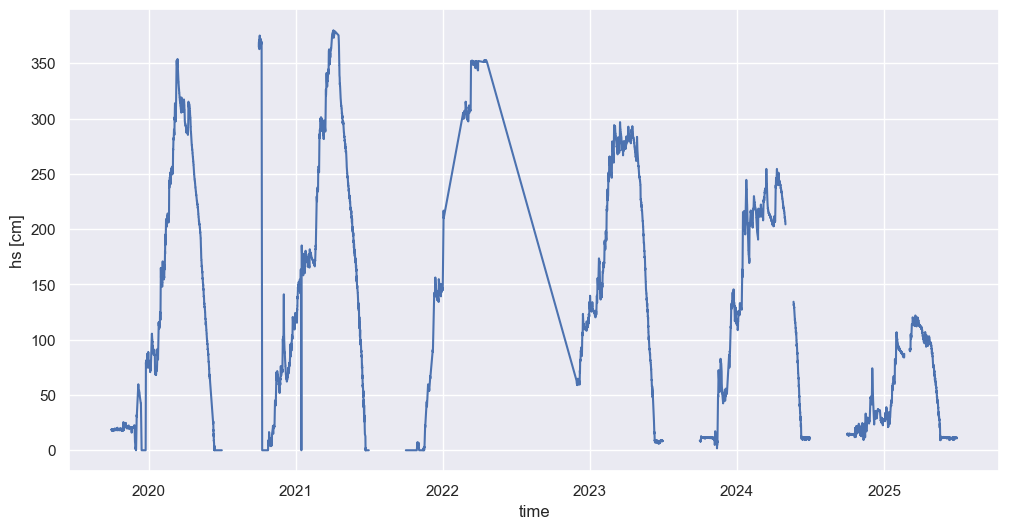

In [45]:
# check the tram snow depth in ds_obs_tram['hs'] and if the rate of change is too high, then remove a few values in a row after that 
# # small cleaning of the hs data which looks awful (remove if I end up doing this somewhere else)
ds_obs_tram['hs'] = ds_obs_tram['hs'].where(~((ds_obs_tram['time'] >= np.datetime64("2024-05-01T00:00")) & (ds_obs_tram['time'] <= np.datetime64("2024-05-20T23:59")))) # the drop in 2024
ds_obs_tram['hs'] = ds_obs_tram['hs'].where(~((ds_obs_tram['time'] >= np.datetime64("2025-02-20T00:00")) & (ds_obs_tram['time'] <= np.datetime64("2025-03-04T23:59")))) # the spike in 2025
# ds_obs_tram['hs'] = ds_obs_tram['hs'].where(~((ds_obs_tram['time'] >= np.datetime64("2025-02-20T00:00")) & (ds_obs_tram['time'] <= np.datetime64("2025-03-04T23:59")))) # more...

# for the tram, shift any values which are below 30 cm in July, August, Sept to 0 
ds_obs_tram['hs'].plot()
ds_obs_tram['hs'] = ds_obs_tram['hs'].where(~((ds_obs_tram['time.month'] >= 7) & (ds_obs_tram['time.month'] <= 9) & (ds_obs_tram['hs'] < 60))) # shift any values which are below 30 cm in July, August, Sept to 0

ds_obs_ppsa['hs'] = ds_obs_ppsa['hs'].where(~((ds_obs_ppsa['time'] >= np.datetime64("2024-08-20T00:00")) & (ds_obs_ppsa['time'] <= np.datetime64("2024-10-15T23:59")))) # the spike in 2025
# ds_obs_ppsa['hs'].plot()

## Plot the sites together

Text(0, 0.5, 'snow depth (cm)')

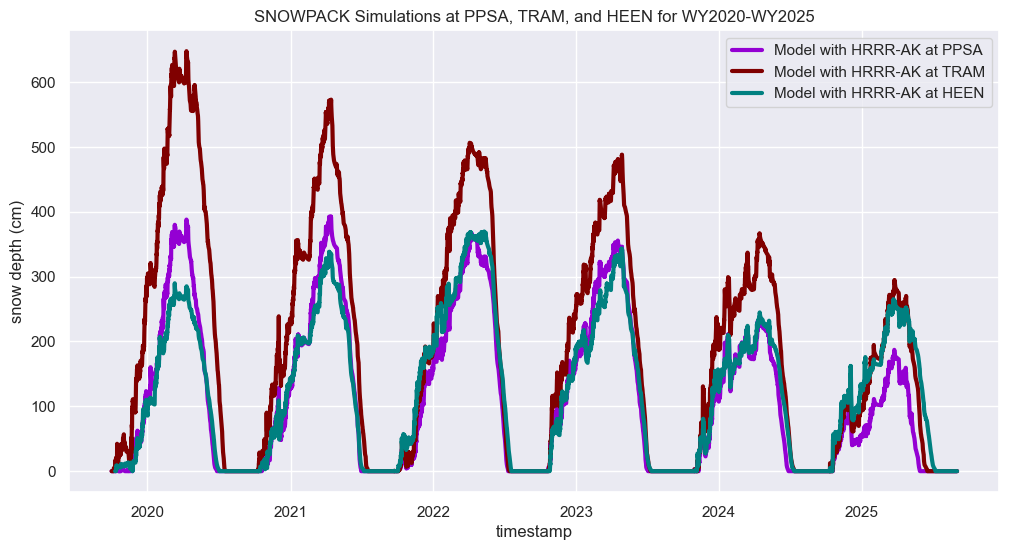

In [8]:
# plot ppsa, tram, and heen together for hrrrak
ds_snowpack_hrrrak_ppsa.HS_mod.plot(label = 'Model with HRRR-AK at PPSA', linewidth = 3, color=ppsa_color)
ds_snowpack_hrrrak_tram.HS_mod.plot(label = 'Model with HRRR-AK at TRAM', linewidth = 3, color=tram_color)
ds_snowpack_hrrrak_heen.HS_mod.plot(label = 'Model with HRRR-AK at HEEN', linewidth = 3, color=heen_color)

# plot the met hrrrak data for each site
# ds_snowpack_met_hrrrak_ppsa.HS_mod.plot(label = 'Model with HRRR-AK Met at PPSA', linewidth = 3, color=met_hrrrak_color, linestyle='--')
# ds_snowpack_met_hrrrak_tram.HS_mod.plot(label = 'Model with HRRR-AK Met at TRAM', linewidth = 3, color=met_hrrrak_color, linestyle='--')
# ds_snowpack_met_hrrrak_heen.HS_mod.plot(label = 'Model with HRRR-AK Met at HEEN', linewidth = 3, color=met_hrrrak_color, linestyle='--')

# plot observations 
# ds_obs_heen.hs.plot(label = 'HEEN Obs', linewidth = 3, color=heen_color, linestyle='--')
# ds_obs_tram.hs.plot(label = 'TRAM Obs', linewidth = 3, color=tram_color, linestyle='--')
# ds_obs_ppsa.hs.plot(label = 'PPSA Obs', linewidth = 3, color=ppsa_color, linestyle='--')


plt.title('SNOWPACK Simulations at PPSA, TRAM, and HEEN for WY2020-WY2025')
plt.legend(loc = 'upper right')

# plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

# Make a Precip Figure for WY2025 

In [10]:
# cut all data to WY2025 only
start_date = "2019-09-01"
end_date = "2025-09-30"


ds_snowpack_hrrrak_ppsa = ds_snowpack_hrrrak_ppsa.sel(timestamp=slice(start_date, end_date))
ds_snowpack_hrrrak_tram = ds_snowpack_hrrrak_tram.sel(timestamp=slice(start_date, end_date))
ds_snowpack_hrrrak_heen = ds_snowpack_hrrrak_heen.sel(timestamp=slice(start_date, end_date))
ds_snowpack_met_hrrrak_ppsa = ds_snowpack_met_hrrrak_ppsa.sel(timestamp=slice(start_date, end_date))
ds_snowpack_met_hrrrak_tram = ds_snowpack_met_hrrrak_tram.sel(timestamp=slice(start_date, end_date))
ds_snowpack_met_hrrrak_heen = ds_snowpack_met_hrrrak_heen.sel(timestamp=slice(start_date, end_date))
ds_obs_heen = ds_obs_heen.sel(time=slice(start_date, end_date))
ds_obs_tram = ds_obs_tram.sel(time=slice(start_date, end_date))
ds_obs_ppsa = ds_obs_ppsa.sel(time=slice(start_date, end_date))

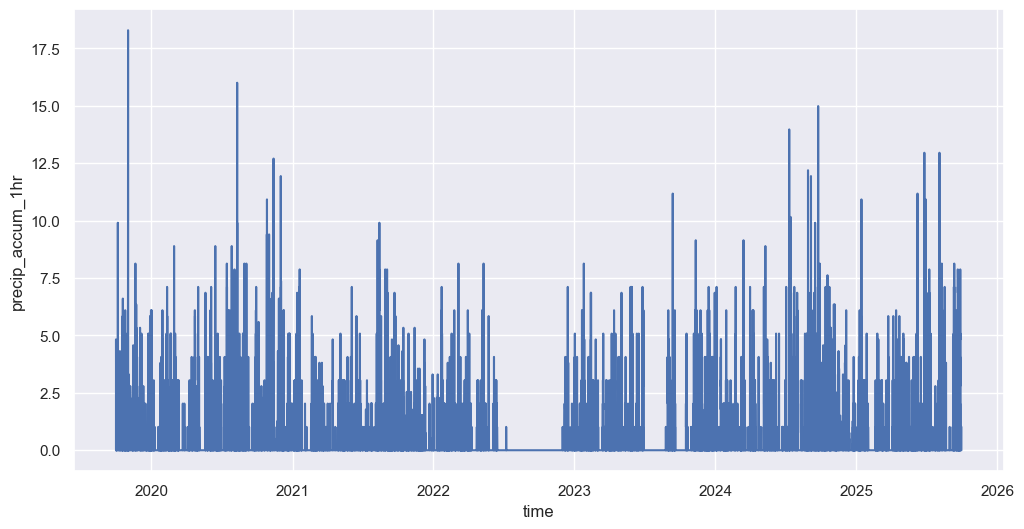

In [16]:
ds_obs_ppsa.precip_accum_1hr.plot()

In [21]:
# look up the attributes for the PSUM24 variable in
ds_snowpack_hrrrak_ppsa.PSUM24

<xarray.DataArray 'PSUM24' (timestamp: 51884)> Size: 415kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(51884,))
Coordinates:
  * timestamp  (timestamp) datetime64[ns] 415kB 2019-10-01T05:00:00 ... 2025-...

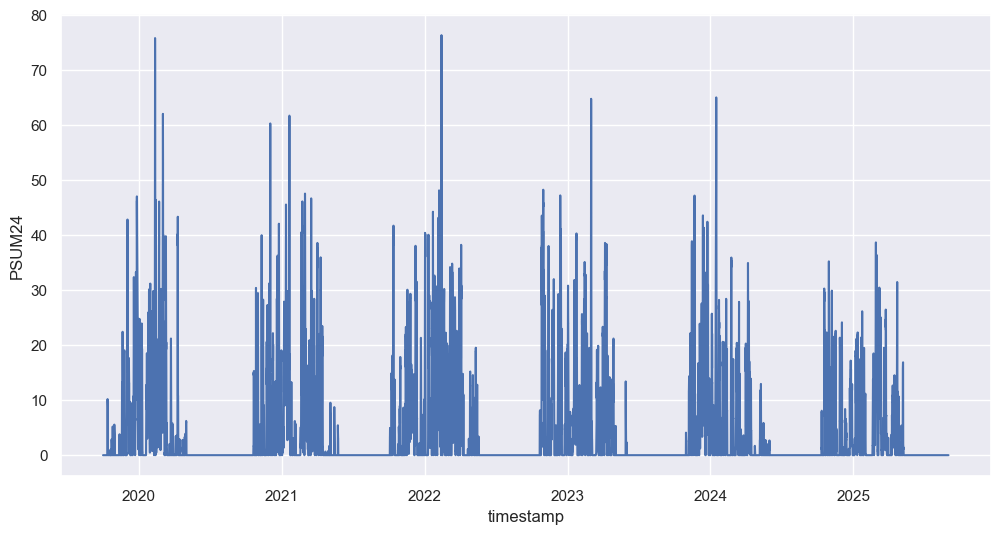

In [25]:
ds_snowpack_hrrrak_ppsa.PSUM24.plot()

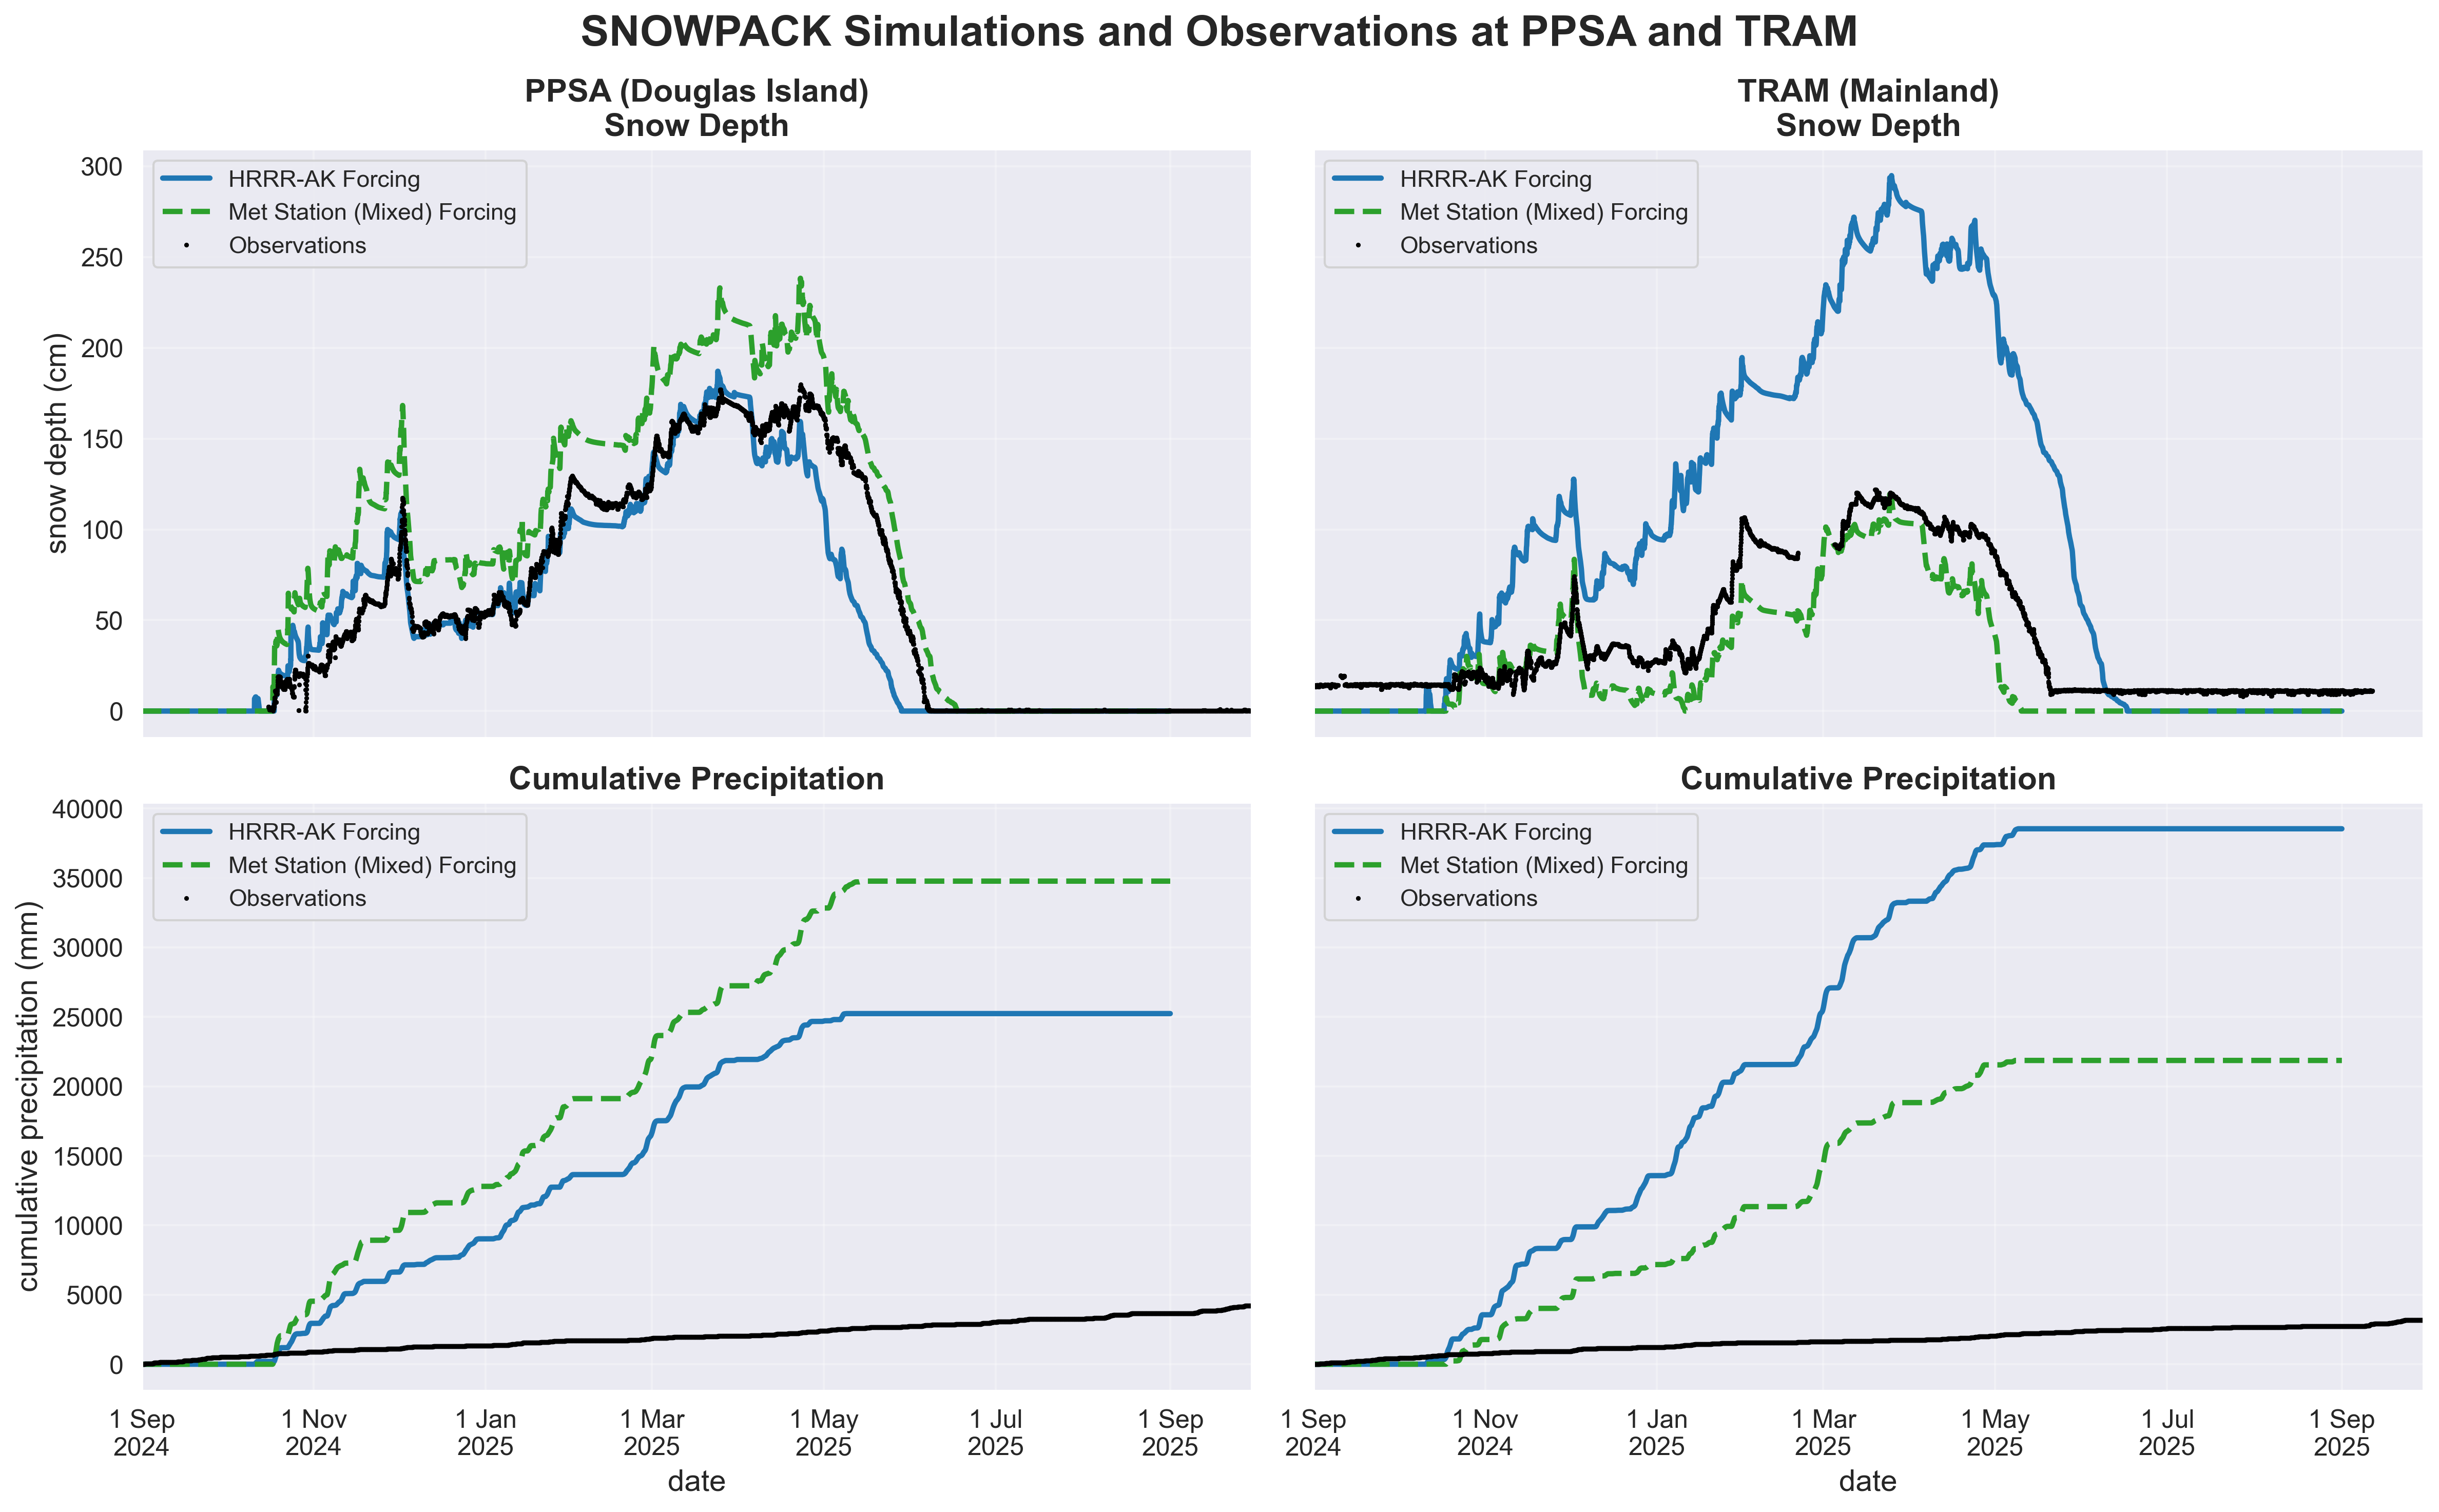

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ============================================================
# Select plotting period
# ============================================================

start_date = "2024-09-01"
end_date   = "2025-09-30"

# ============================================================
# Subset datasets
# ============================================================

# PPSA
ds_hrrr_ppsa = ds_snowpack_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)

ds_met_ppsa = ds_snowpack_met_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)

ds_obs_ppsa_plot = ds_obs_ppsa.sel(
    time=slice(start_date, end_date)
)

# TRAM
ds_hrrr_tram = ds_snowpack_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

ds_met_tram = ds_snowpack_met_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

ds_obs_tram_plot = ds_obs_tram.sel(
    time=slice(start_date, end_date)
)

# ============================================================
# Adjustable manuscript plotting settings
# ============================================================

fig_width = 16
fig_height = 10
dpi = 300

title_fontsize = 20
subplot_title_fontsize = 15
axis_label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 11

model_linewidth = 2.5
obs_markersize = 1.2

spine_width = 1.2

# ============================================================
# Colors
# ============================================================

hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'black'

# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(fig_width, fig_height),
    dpi=dpi,
    sharex='col',
    sharey='row'
)

# ============================================================
# Axes assignment
# ============================================================

ax_sd_ppsa = axes[0, 0]
ax_sd_tram = axes[0, 1]

ax_ppt_ppsa = axes[1, 0]
ax_ppt_tram = axes[1, 1]

# ============================================================
# ---------------- TOP ROW: SNOW DEPTH -----------------------
# ============================================================

# ------------------------------------------------------------
# PPSA Snow Depth
# ------------------------------------------------------------

ds_hrrr_ppsa.HS_mod.plot(
    ax=ax_sd_ppsa,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_met_ppsa.HS_mod.plot(
    ax=ax_sd_ppsa,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

ds_obs_ppsa_plot.hs.plot(
    ax=ax_sd_ppsa,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

# ------------------------------------------------------------
# TRAM Snow Depth
# ------------------------------------------------------------

ds_hrrr_tram.HS_mod.plot(
    ax=ax_sd_tram,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_met_tram.HS_mod.plot(
    ax=ax_sd_tram,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

ds_obs_tram_plot.hs.plot(
    ax=ax_sd_tram,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

# ============================================================
# ------------- BOTTOM ROW: PRECIPITATION --------------------
# ============================================================

# ------------------------------------------------------------
# PPSA Precipitation
# ------------------------------------------------------------

ds_hrrr_ppsa.PSUM24.cumsum().plot(
    ax=ax_ppt_ppsa,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_met_ppsa.PSUM24.cumsum().plot(
    ax=ax_ppt_ppsa,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

ds_obs_ppsa_plot.precip_accum_1hr.cumsum().plot(
    ax=ax_ppt_ppsa,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

# ------------------------------------------------------------
# TRAM Precipitation
# ------------------------------------------------------------

ds_hrrr_tram.PSUM24.cumsum().plot(
    ax=ax_ppt_tram,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_met_tram.PSUM24.cumsum().plot(
    ax=ax_ppt_tram,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

ds_obs_tram_plot.precip_accum_1hr.cumsum().plot(
    ax=ax_ppt_tram,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

# ============================================================
# Titles
# ============================================================

ax_sd_ppsa.set_title(
    'PPSA (Douglas Island)\nSnow Depth',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_sd_tram.set_title(
    'TRAM (Mainland)\nSnow Depth',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_ppt_ppsa.set_title(
    'Cumulative Precipitation',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_ppt_tram.set_title(
    'Cumulative Precipitation',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

# ============================================================
# Axis labels
# ============================================================

ax_sd_ppsa.set_ylabel(
    'snow depth (cm)',
    fontsize=axis_label_fontsize
)

ax_ppt_ppsa.set_ylabel(
    'cumulative precipitation (mm)',
    fontsize=axis_label_fontsize
)

ax_ppt_ppsa.set_xlabel(
    'date',
    fontsize=axis_label_fontsize
)

ax_ppt_tram.set_xlabel(
    'date',
    fontsize=axis_label_fontsize
)

# ============================================================
# Date formatting
# ============================================================

# major_locator = mdates.MonthLocator(
#     bymonth=[1, 6, 10]
# )

major_formatter = mdates.DateFormatter(
    '%-d %b\n%Y'
)

for ax in axes.flatten():

    # ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=tick_fontsize,
        width=1.2,
        length=5
    )

    # Grid
    ax.grid(alpha=0.3)

    # Spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)

# ============================================================
# Legends
# ============================================================

for ax in axes.flatten():

    ax.legend(
        fontsize=legend_fontsize,
        loc='upper left',
        frameon=True
    )

# ============================================================
# Set consistent x-limits
# ============================================================

for ax in axes.flatten():

    ax.set_xlim(
        pd.Timestamp(start_date),
        pd.Timestamp(end_date)
    )

# remove the labels from the xais first row 
for ax in axes[0, :]:
    ax.set_xlabel('')
    
# also remove the extra y-axis labels on column 2
axes[0, 1].set_ylabel('')
axes[1, 1].set_ylabel('')     
    

# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    'SNOWPACK Simulations and Observations at PPSA and TRAM',
    fontsize=title_fontsize,
    fontweight='bold'
)

# ============================================================
# Layout
# ============================================================

fig.tight_layout()

# ============================================================
# Save figure
# ============================================================

# plt.savefig(
#     'snowpack_ppsa_tram_comparison.png',
#     dpi=300,
#     bbox_inches='tight'
# )

# plt.savefig(
#     'snowpack_ppsa_tram_comparison.pdf',
#     bbox_inches='tight'
# )

plt.show()

Going to need to load the SMET forcing data to get the precipiations to compare, 

In [37]:
ds_forcing_hrrrak_ppsa, header_hrrrak_ppsa =     read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/input/hrrrak_WY2020-WY2025/hrrrak_ppsa_WY2020-WY2025.smet")
ds_forcing_met_hrrrak_ppsa, header_hrrrak_ppsa = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/input/met_hrrrak_WY2023-WY2025/met_hrrrak_ppsa_WY2023-WY2025.smet")

/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [38]:
ds_forcing_hrrrak_tram, header_hrrrak_tram =     read_smet("/home/cassie/python/models/run_snowpack/sites/tram/input/hrrrak_WY2020-WY2025/hrrrak_tram_WY2020-WY2025.smet")
ds_forcing_met_hrrrak_tram, header_hrrrak_tram = read_smet("/home/cassie/python/models/run_snowpack/sites/tram/input/met_hrrrak_WY2023-WY2025/met_hrrrak_tram_WY2023-WY2025.smet")

/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_155118/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


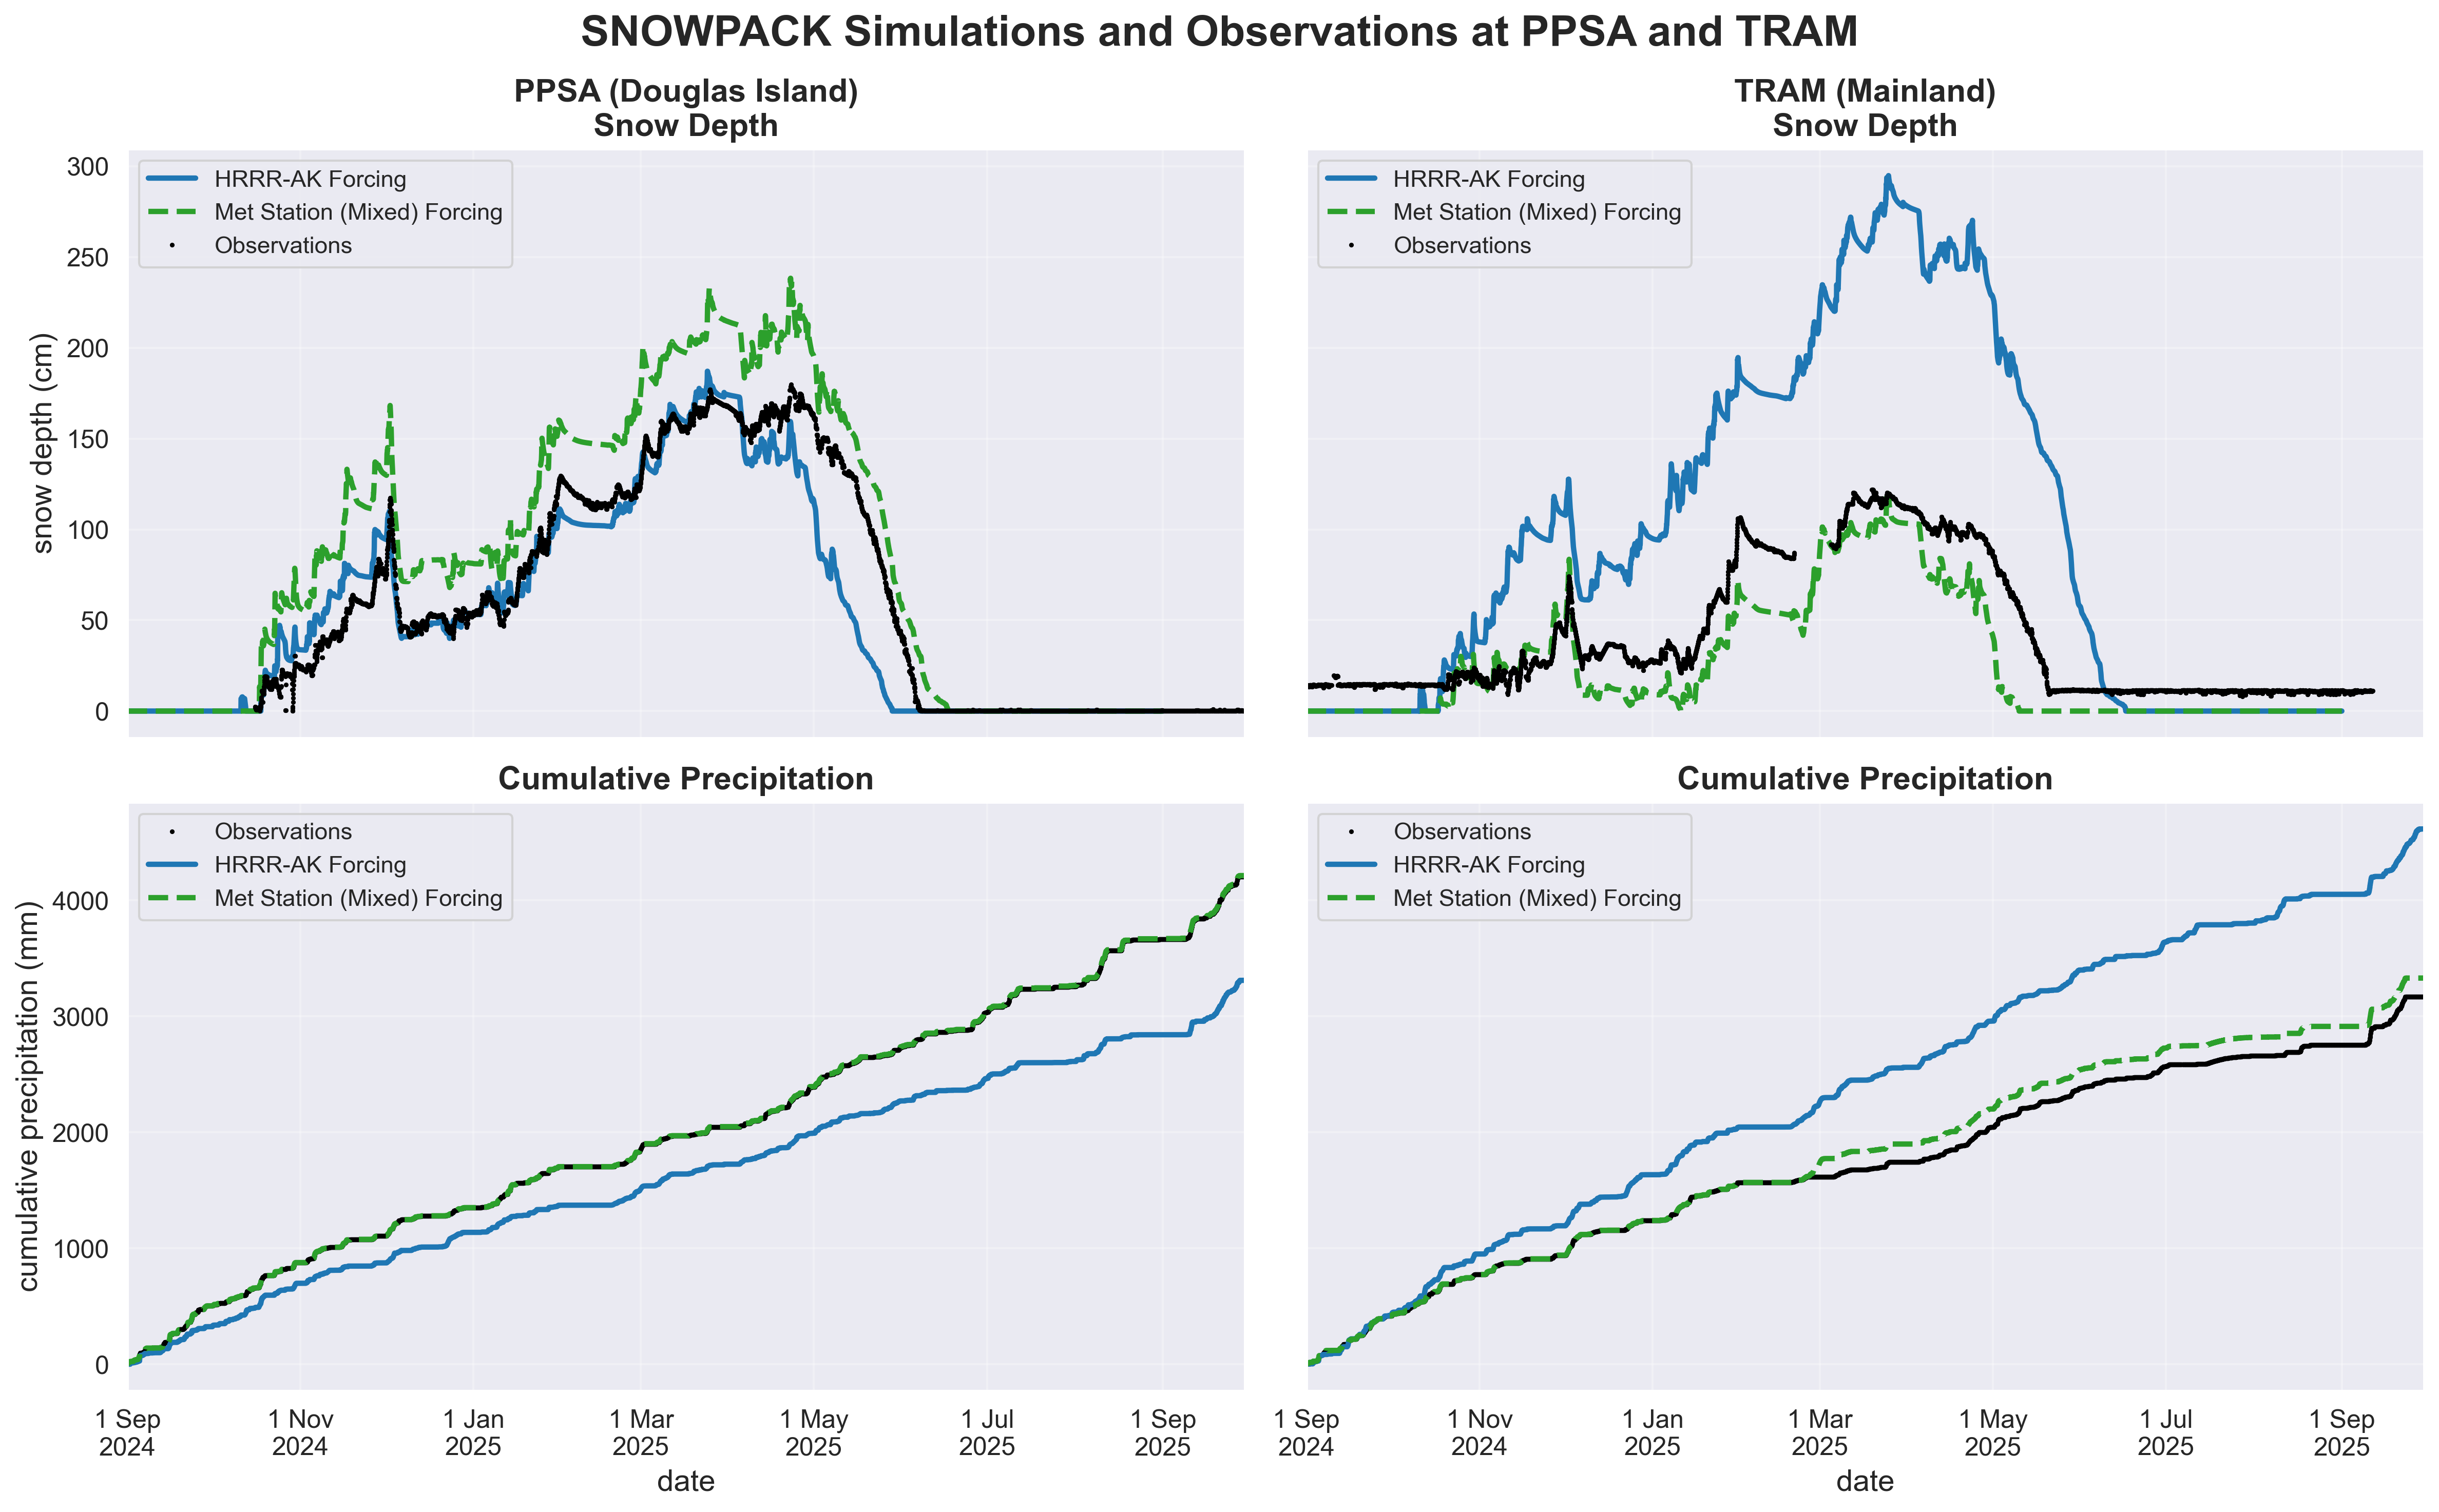

In [40]:
# ============================================================
# Select plotting period
# ============================================================

start_date = "2024-09-01"
end_date   = "2025-09-30"

# ============================================================
# Subset datasets
# ============================================================

# PPSA
ds_hrrr_ppsa = ds_snowpack_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)

ds_met_ppsa = ds_snowpack_met_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)

ds_obs_ppsa_plot = ds_obs_ppsa.sel(
    time=slice(start_date, end_date)
)

# add in th forcing data for the precip plot to compare the correct data 
ds_forcing_hrrrak_ppsa = ds_forcing_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)

ds_forcing_met_hrrrak_ppsa = ds_forcing_met_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)


# TRAM
ds_hrrr_tram = ds_snowpack_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

ds_met_tram = ds_snowpack_met_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

ds_obs_tram_plot = ds_obs_tram.sel(
    time=slice(start_date, end_date)
)

# add in the forcing data for the precip plot 
ds_forcing_hrrrak_tram = ds_forcing_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

ds_forcing_met_hrrrak_tram = ds_forcing_met_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

# ============================================================
# Adjustable manuscript plotting settings
# ============================================================

fig_width = 16
fig_height = 10
dpi = 300

title_fontsize = 20
subplot_title_fontsize = 15
axis_label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 11

model_linewidth = 2.5
obs_markersize = 1.2

spine_width = 1.2

# ============================================================
# Colors
# ============================================================

hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'black'

# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(fig_width, fig_height),
    dpi=dpi,
    sharex='col',
    sharey='row'
)

# ============================================================
# Axes assignment
# ============================================================

ax_sd_ppsa = axes[0, 0]
ax_sd_tram = axes[0, 1]

ax_ppt_ppsa = axes[1, 0]
ax_ppt_tram = axes[1, 1]

# ============================================================
# ---------------- TOP ROW: SNOW DEPTH -----------------------
# ============================================================

# ------------------------------------------------------------
# PPSA Snow Depth
# ------------------------------------------------------------

ds_hrrr_ppsa.HS_mod.plot(
    ax=ax_sd_ppsa,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_met_ppsa.HS_mod.plot(
    ax=ax_sd_ppsa,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

ds_obs_ppsa_plot.hs.plot(
    ax=ax_sd_ppsa,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

# ------------------------------------------------------------
# TRAM Snow Depth
# ------------------------------------------------------------

ds_hrrr_tram.HS_mod.plot(
    ax=ax_sd_tram,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_met_tram.HS_mod.plot(
    ax=ax_sd_tram,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

ds_obs_tram_plot.hs.plot(
    ax=ax_sd_tram,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

# ============================================================
# ------------- BOTTOM ROW: PRECIPITATION --------------------
# ============================================================

# ------------------------------------------------------------
# PPSA Precipitation
# ------------------------------------------------------------

ds_obs_ppsa_plot.precip_accum_1hr.cumsum().plot(
    ax=ax_ppt_ppsa,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)


ds_forcing_hrrrak_ppsa.PSUM.cumsum().plot(
    ax=ax_ppt_ppsa,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_forcing_met_hrrrak_ppsa.PSUM.cumsum().plot(
    ax=ax_ppt_ppsa,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)


# ------------------------------------------------------------
# TRAM Precipitation
# ------------------------------------------------------------

ds_obs_tram_plot.precip_accum_1hr.cumsum().plot(
    ax=ax_ppt_tram,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

ds_forcing_hrrrak_tram.PSUM.cumsum().plot(
    ax=ax_ppt_tram,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_forcing_met_hrrrak_tram.PSUM.cumsum().plot(
    ax=ax_ppt_tram,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

# ============================================================
# Titles
# ============================================================

ax_sd_ppsa.set_title(
    'PPSA (Douglas Island)\nSnow Depth',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_sd_tram.set_title(
    'TRAM (Mainland)\nSnow Depth',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_ppt_ppsa.set_title(
    'Cumulative Precipitation',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_ppt_tram.set_title(
    'Cumulative Precipitation',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

# ============================================================
# Axis labels
# ============================================================

ax_sd_ppsa.set_ylabel(
    'snow depth (cm)',
    fontsize=axis_label_fontsize
)

ax_ppt_ppsa.set_ylabel(
    'cumulative precipitation (mm)',
    fontsize=axis_label_fontsize
)

ax_ppt_ppsa.set_xlabel(
    'date',
    fontsize=axis_label_fontsize
)

ax_ppt_tram.set_xlabel(
    'date',
    fontsize=axis_label_fontsize
)

# ============================================================
# Date formatting
# ============================================================

# major_locator = mdates.MonthLocator(
#     bymonth=[1, 6, 10]
# )

major_formatter = mdates.DateFormatter(
    '%-d %b\n%Y'
)

for ax in axes.flatten():

    # ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=tick_fontsize,
        width=1.2,
        length=5
    )

    # Grid
    ax.grid(alpha=0.3)

    # Spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)

# ============================================================
# Legends
# ============================================================

for ax in axes.flatten():

    ax.legend(
        fontsize=legend_fontsize,
        loc='upper left',
        frameon=True
    )

# ============================================================
# Set consistent x-limits
# ============================================================

for ax in axes.flatten():

    ax.set_xlim(
        pd.Timestamp(start_date),
        pd.Timestamp(end_date)
    )

# remove the labels from the xais first row 
for ax in axes[0, :]:
    ax.set_xlabel('')
    
# also remove the extra y-axis labels on column 2
axes[0, 1].set_ylabel('')
axes[1, 1].set_ylabel('')     
    

# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    'SNOWPACK Simulations and Observations at PPSA and TRAM',
    fontsize=title_fontsize,
    fontweight='bold'
)

# ============================================================
# Layout
# ============================================================

fig.tight_layout()

# ============================================================
# Save figure
# ============================================================

# plt.savefig(
#     'snowpack_ppsa_tram_comparison.png',
#     dpi=300,
#     bbox_inches='tight'
# )

# plt.savefig(
#     'snowpack_ppsa_tram_comparison.pdf',
#     bbox_inches='tight'
# )

plt.show()

Now, add a subplot row which is just precip_accum_1hr within cumsum 

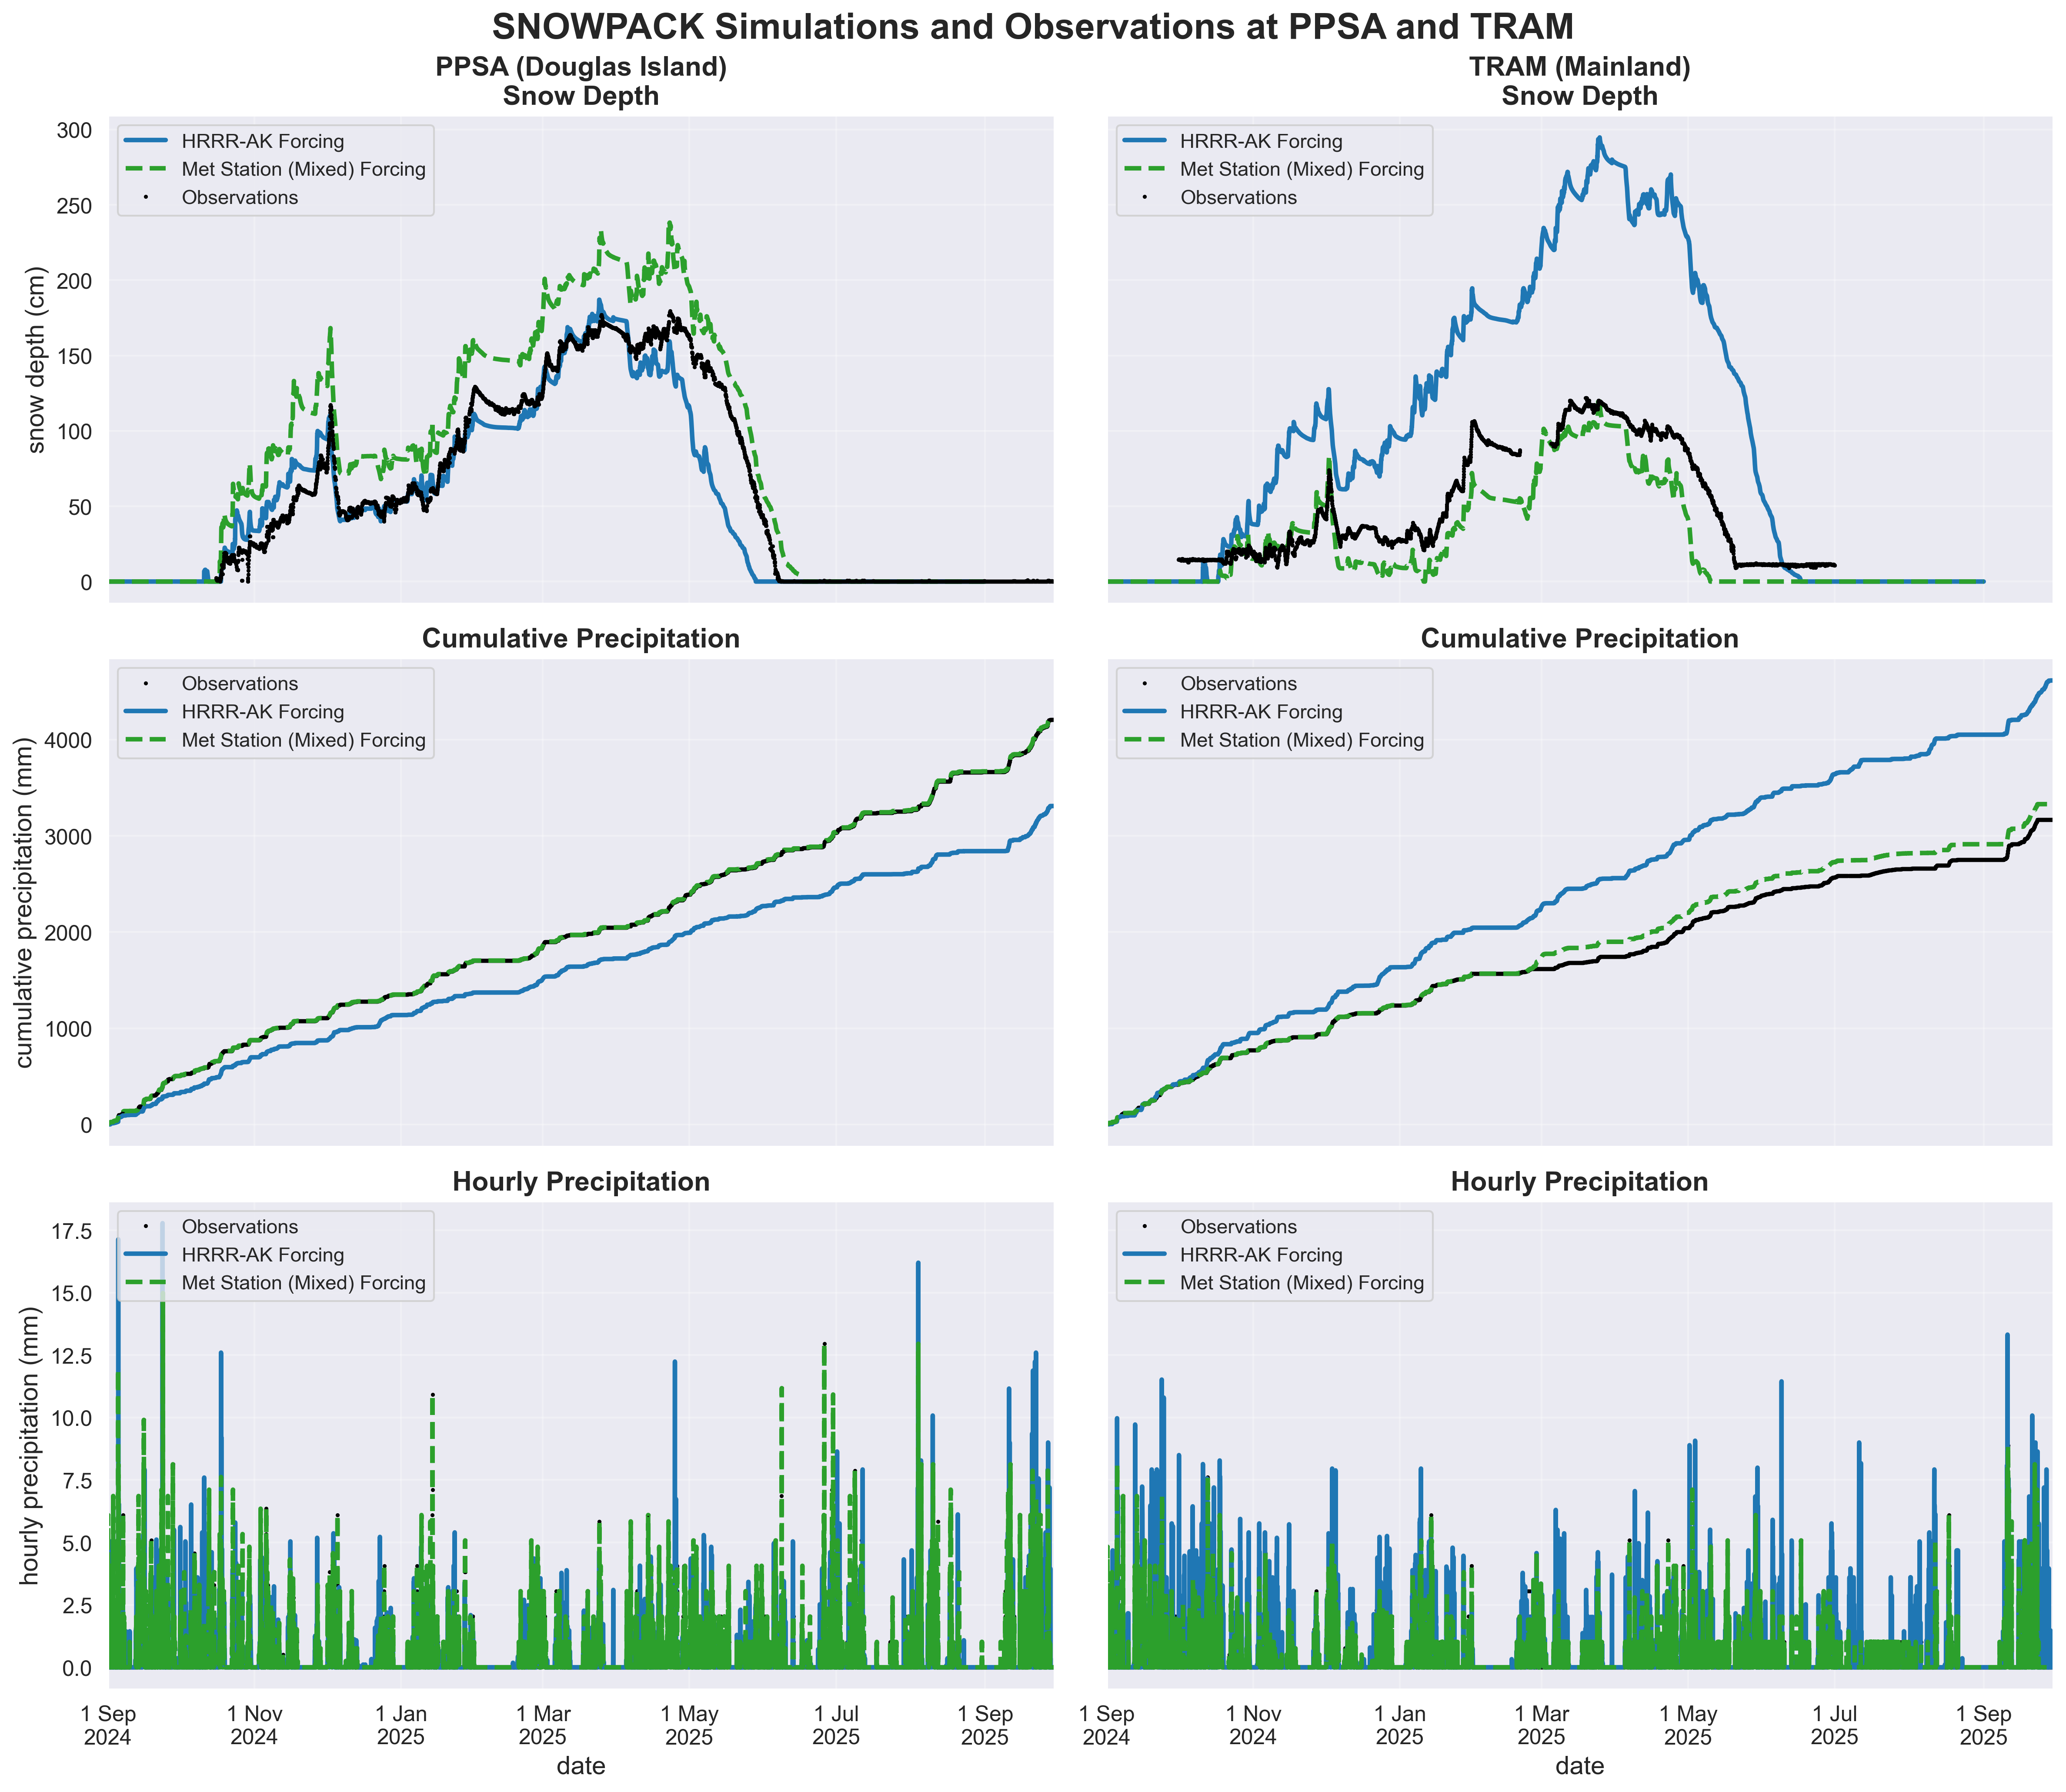

In [48]:
# ============================================================
# Select plotting period
# ============================================================

start_date = "2024-09-01"
end_date   = "2025-09-30"

# ============================================================
# Subset datasets
# ============================================================

# PPSA
ds_hrrr_ppsa = ds_snowpack_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)

ds_met_ppsa = ds_snowpack_met_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)

ds_obs_ppsa_plot = ds_obs_ppsa.sel(
    time=slice(start_date, end_date)
)

# add in th forcing data for the precip plot to compare the correct data 
ds_forcing_hrrrak_ppsa = ds_forcing_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)

ds_forcing_met_hrrrak_ppsa = ds_forcing_met_hrrrak_ppsa.sel(
    timestamp=slice(start_date, end_date)
)


# TRAM
ds_hrrr_tram = ds_snowpack_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

ds_met_tram = ds_snowpack_met_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

ds_obs_tram_plot = ds_obs_tram.sel(
    time=slice(start_date, end_date)
)

# add in the forcing data for the precip plot 
ds_forcing_hrrrak_tram = ds_forcing_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

ds_forcing_met_hrrrak_tram = ds_forcing_met_hrrrak_tram.sel(
    timestamp=slice(start_date, end_date)
)

# ============================================================
# Adjustable manuscript plotting settings
# ============================================================

fig_width = 16
fig_height = 14
dpi = 300

title_fontsize = 20
subplot_title_fontsize = 15
axis_label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 11

model_linewidth = 2.5
obs_markersize = 1.2

spine_width = 1.2

# ============================================================
# Colors
# ============================================================

hrrrak_color = 'tab:blue'
met_hrrrak_color = 'tab:green'
obs_color = 'black'

# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(fig_width, fig_height),
    dpi=dpi,
    sharex='col',
    sharey='row'
)

# ============================================================
# Axes assignment
# ============================================================

ax_sd_ppsa = axes[0, 0]
ax_sd_tram = axes[0, 1]

ax_ppt_ppsa = axes[1, 0]
ax_ppt_tram = axes[1, 1]

ax_ppt_hourly_ppsa = axes[2, 0]
ax_ppt_hourly_tram = axes[2, 1]

# ============================================================
# ---------------- TOP ROW: SNOW DEPTH -----------------------
# ============================================================

# ------------------------------------------------------------
# PPSA Snow Depth
# ------------------------------------------------------------

ds_hrrr_ppsa.HS_mod.plot(
    ax=ax_sd_ppsa,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_met_ppsa.HS_mod.plot(
    ax=ax_sd_ppsa,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

ds_obs_ppsa_plot.hs.plot(
    ax=ax_sd_ppsa,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

# ------------------------------------------------------------
# TRAM Snow Depth
# ------------------------------------------------------------

ds_hrrr_tram.HS_mod.plot(
    ax=ax_sd_tram,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_met_tram.HS_mod.plot(
    ax=ax_sd_tram,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

ds_obs_tram_plot.hs.plot(
    ax=ax_sd_tram,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

# ============================================================
# ------- MIDDLE ROW: CUMULATIVE PRECIPITATION ---------------
# ============================================================

# ------------------------------------------------------------
# PPSA Cumulative Precipitation
# ------------------------------------------------------------

ds_obs_ppsa_plot.precip_accum_1hr.cumsum().plot(
    ax=ax_ppt_ppsa,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

ds_forcing_hrrrak_ppsa.PSUM.cumsum().plot(
    ax=ax_ppt_ppsa,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_forcing_met_hrrrak_ppsa.PSUM.cumsum().plot(
    ax=ax_ppt_ppsa,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

# ------------------------------------------------------------
# TRAM Cumulative Precipitation
# ------------------------------------------------------------

ds_obs_tram_plot.precip_accum_1hr.cumsum().plot(
    ax=ax_ppt_tram,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

ds_forcing_hrrrak_tram.PSUM.cumsum().plot(
    ax=ax_ppt_tram,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_forcing_met_hrrrak_tram.PSUM.cumsum().plot(
    ax=ax_ppt_tram,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

# ============================================================
# -------- BOTTOM ROW: HOURLY PRECIPITATION ------------------
# ============================================================

# ------------------------------------------------------------
# PPSA Hourly Precipitation
# ------------------------------------------------------------

ds_obs_ppsa_plot.precip_accum_1hr.plot(
    ax=ax_ppt_hourly_ppsa,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

ds_forcing_hrrrak_ppsa.PSUM.plot(
    ax=ax_ppt_hourly_ppsa,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_forcing_met_hrrrak_ppsa.PSUM.plot(
    ax=ax_ppt_hourly_ppsa,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

# ------------------------------------------------------------
# TRAM Hourly Precipitation
# ------------------------------------------------------------

ds_obs_tram_plot.precip_accum_1hr.plot(
    ax=ax_ppt_hourly_tram,
    color=obs_color,
    linestyle='None',
    marker='o',
    markersize=obs_markersize,
    label='Observations'
)

ds_forcing_hrrrak_tram.PSUM.plot(
    ax=ax_ppt_hourly_tram,
    color=hrrrak_color,
    linewidth=model_linewidth,
    label='HRRR-AK Forcing'
)

ds_forcing_met_hrrrak_tram.PSUM.plot(
    ax=ax_ppt_hourly_tram,
    color=met_hrrrak_color,
    linewidth=model_linewidth,
    linestyle='--',
    label='Met Station (Mixed) Forcing'
)

# ============================================================
# Titles
# ============================================================

ax_sd_ppsa.set_title(
    'PPSA (Douglas Island)\nSnow Depth',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_sd_tram.set_title(
    'TRAM (Mainland)\nSnow Depth',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_ppt_ppsa.set_title(
    'Cumulative Precipitation',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_ppt_tram.set_title(
    'Cumulative Precipitation',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_ppt_hourly_ppsa.set_title(
    'Hourly Precipitation',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

ax_ppt_hourly_tram.set_title(
    'Hourly Precipitation',
    fontsize=subplot_title_fontsize,
    fontweight='bold'
)

# ============================================================
# Axis labels
# ============================================================

ax_sd_ppsa.set_ylabel(
    'snow depth (cm)',
    fontsize=axis_label_fontsize
)

ax_ppt_ppsa.set_ylabel(
    'cumulative precipitation (mm)',
    fontsize=axis_label_fontsize
)

ax_ppt_hourly_ppsa.set_ylabel(
    'hourly precipitation (mm)',
    fontsize=axis_label_fontsize
)

ax_ppt_hourly_ppsa.set_xlabel(
    'date',
    fontsize=axis_label_fontsize
)

ax_ppt_hourly_tram.set_xlabel(
    'date',
    fontsize=axis_label_fontsize
)

# ============================================================
# Date formatting
# ============================================================

major_formatter = mdates.DateFormatter(
    '%-d %b\n%Y'
)

for ax in axes.flatten():

    ax.xaxis.set_major_formatter(major_formatter)

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=tick_fontsize,
        width=1.2,
        length=5
    )

    # Grid
    ax.grid(alpha=0.3)

    # Spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)

# ============================================================
# Legends
# ============================================================

for ax in axes.flatten():

    ax.legend(
        fontsize=legend_fontsize,
        loc='upper left',
        frameon=True
    )

# ============================================================
# Set consistent x-limits
# ============================================================

for ax in axes.flatten():

    ax.set_xlim(
        pd.Timestamp(start_date),
        pd.Timestamp(end_date)
    )

# remove the labels from the x-axis for first two rows 
# for ax in axes[0:2, :]:
#     ax.set_xlabel('')
    
# also remove the extra y-axis labels on column 2
axes[0, 0].set_xlabel('')
axes[1, 0].set_xlabel('')
axes[0, 1].set_xlabel('')
axes[1, 1].set_xlabel('')

axes[0, 1].set_ylabel('')
axes[1, 1].set_ylabel('')
axes[2, 1].set_ylabel('')

# ============================================================
# Figure title
# ============================================================

fig.suptitle(
    'SNOWPACK Simulations and Observations at PPSA and TRAM',
    fontsize=title_fontsize,
    fontweight='bold'
)

# ============================================================
# Layout
# ============================================================

fig.tight_layout()

# ============================================================
# Save figure
# ============================================================

# plt.savefig(
#     'snowpack_ppsa_tram_comparison.png',
#     dpi=300,
#     bbox_inches='tight'
# )

# plt.savefig(
#     'snowpack_ppsa_tram_comparison.pdf',
#     bbox_inches='tight'
# )

plt.show()